In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split




# from tensorflow.keras import layers, models
# from tensorflow.python.keras import layers

In [186]:
applications = pd.read_csv('application.csv')
offers = pd.read_csv('offers.csv')

In [187]:
# Initial Data Inspection 
print(applications.head())

      salesName applic_status_name  age  appliedAmount civilStatus  \
0           NaN         Closed App   32        42000.0      single   
1           NaN         Closed App   29        10000.0     married   
2  Sales rep  C        Expired App   51        60000.0     married   
3  Sales rep  C        Expired App   52        10000.0     married   
4  Sales rep  C         Closed App   33         2000.0     married   

          loanPurpose  monthlyIncome nationality residency       workStatus  \
0  debt-consolidation         3200.0          SG         s  employed-salary   
1  debt-consolidation         3000.0          SG         s  employed-salary   
2  business-expansion         6200.0          SG         s    self-employed   
3  debt-consolidation         3120.0          SG         s  employed-salary   
4        paying-bills         3400.0          SG         s  employed-salary   

  jobIndustry          applicationTime     appId leadSource  
0  government  2022-03-17 13:28:48.513  Ap

In [188]:
print(offers.head())

          pendingOfferTime           offerGivenTime offerChosenTime  \
0                      NaN                      NaN             NaN   
1  2022-04-01 02:08:26.178  2022-04-01 02:25:48.247             NaN   
2                      NaN                      NaN             NaN   
3                      NaN                      NaN             NaN   
4  2022-04-01 02:08:26.179  2022-04-01 15:29:56.263             NaN   

  disburseTime  offer_status_name lenderName     appId   offerId  
0          NaN             Queued  Lender 01  App 3692  8030317a  
1          NaN  Bank Approved IPA  Lender 02  App 3692  80303179  
2          NaN             Queued  Lender 03  App 3692  80303178  
3          NaN             Queued  Lender 04  App 3692  80303177  
4          NaN  Bank Approved IPA  Lender 05  App 3692  80303176  


In [189]:
print(applications.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3692 entries, 0 to 3691
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   salesName           3630 non-null   object 
 1   applic_status_name  3692 non-null   object 
 2   age                 3692 non-null   int64  
 3   appliedAmount       3692 non-null   float64
 4   civilStatus         3692 non-null   object 
 5   loanPurpose         3692 non-null   object 
 6   monthlyIncome       3692 non-null   float64
 7   nationality         3692 non-null   object 
 8   residency           3692 non-null   object 
 9   workStatus          3692 non-null   object 
 10  jobIndustry         3685 non-null   object 
 11  applicationTime     3692 non-null   object 
 12  appId               3692 non-null   object 
 13  leadSource          3692 non-null   object 
dtypes: float64(2), int64(1), object(11)
memory usage: 403.9+ KB
None


In [190]:
print(offers.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131665 entries, 0 to 131664
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   pendingOfferTime   61191 non-null   object
 1   offerGivenTime     25601 non-null   object
 2   offerChosenTime    2023 non-null    object
 3   disburseTime       610 non-null     object
 4   offer_status_name  131665 non-null  object
 5   lenderName         131665 non-null  object
 6   appId              131665 non-null  object
 7   offerId            131665 non-null  object
dtypes: object(8)
memory usage: 8.0+ MB
None


In [191]:
print(applications.describe())

               age  appliedAmount  monthlyIncome
count  3692.000000    3692.000000   3.692000e+03
mean     36.465330   18105.135970   4.772046e+03
std      10.236125   25354.451408   3.960365e+04
min      18.000000    1000.000000   0.000000e+00
25%      29.000000    5000.000000   2.371750e+03
50%      34.000000   10000.000000   3.000000e+03
75%      42.000000   20000.000000   4.300000e+03
max      79.000000  250000.000000   2.382323e+06


In [192]:
print(offers.describe())

               pendingOfferTime           offerGivenTime  \
count                     61191                    25601   
unique                    25831                    25601   
top     2022-02-23 12:53:03.422  2022-04-01 02:25:48.247   
freq                         13                        1   

                offerChosenTime             disburseTime offer_status_name  \
count                      2023                      610            131665   
unique                     2023                      610                12   
top     2022-04-01 14:50:34.889  2022-04-01 18:38:38.592            Queued   
freq                          1                        1             45097   

       lenderName     appId   offerId  
count      131665    131665    131665  
unique         36      3692    131665  
top     Lender 10  App 2450  8030317a  
freq         7380        37         1  


In [193]:
print(applications.isnull().sum())

salesName             62
applic_status_name     0
age                    0
appliedAmount          0
civilStatus            0
loanPurpose            0
monthlyIncome          0
nationality            0
residency              0
workStatus             0
jobIndustry            7
applicationTime        0
appId                  0
leadSource             0
dtype: int64


In [194]:
applications[applications['jobIndustry'].isna()]

,salesName,applic_status_name,age,appliedAmount,civilStatus,loanPurpose,monthlyIncome,nationality,residency,workStatus,jobIndustry,applicationTime,appId,leadSource
7,Sales rep F,Closed App,40,50000.0,married,debt-consolidation-ff,4500.0,LB,ep,unemployed,NaN,2022-01-04 01:27:15.397,App 0008,facebook
1231,Sales rep F,Closed App,75,14000.0,married,renovation,2000.0,SG,s,retired,NaN,2022-02-02 18:04:54.606,App 1232,direct
1330,Sales rep I,Bank Declined App,49,20000.0,married,paying-bills,3500.0,SG,s,retired,NaN,2022-02-05 02:34:56.674,App 1331,facebook
2411,Sales rep F,Bank Declined App,22,1500.0,single,paying-bills,2500.0,SG,s,unemployed,NaN,2022-03-03 06:49:31.51,App 2412,facebook
3442,Sales rep I,Bank Declined App,39,30000.0,single,debt-consolidation,4000.0,SG,s,unemployed,NaN,2022-03-26 18:44:36.664,App 3443,facebook
3508,Sales rep F,Bank Declined App,35,140000.0,married,paying-bills,2000.0,SG,s,unemployed,NaN,2022-03-28 11:16:32.553,App 3509,nestia
3666,Sales rep F,Closed App,39,20000.0,single,other,2000.0,SG,s,unemployed,NaN,2022-03-31 15:40:37.483,App 3667,yahoo


In [195]:
print(offers.isnull().sum())

pendingOfferTime      70474
offerGivenTime       106064
offerChosenTime      129642
disburseTime         131055
offer_status_name         0
lenderName                0
appId                     0
offerId                   0
dtype: int64


In [196]:
applications['applicationTime'] = pd.to_datetime(applications['applicationTime'])
# applications['application_month'] = applications['applicationTime'].dt.month
# applications['days_since_application'] = (pd.to_datetime('now') - applications['applicationTime']).dt.days
applications.head()

,salesName,applic_status_name,age,appliedAmount,civilStatus,loanPurpose,monthlyIncome,nationality,residency,workStatus,jobIndustry,applicationTime,appId,leadSource
0,NaN,Closed App,32,42000.0,single,debt-consolidation,3200.0,SG,s,employed-salary,government,2022-03-17 13:28:48.513,App 0001,Google
1,NaN,Closed App,29,10000.0,married,debt-consolidation,3000.0,SG,s,employed-salary,government,2022-03-17 13:28:48.512,App 0002,Google
2,Sales rep C,Expired App,51,60000.0,married,business-expansion,6200.0,SG,s,self-employed,retail,2022-01-05 14:37:25.759,App 0003,e-mail
3,Sales rep C,Expired App,52,10000.0,married,debt-consolidation,3120.0,SG,s,employed-salary,government,2022-01-07 23:13:56.093,App 0004,google
4,Sales rep C,Closed App,33,2000.0,married,paying-bills,3400.0,SG,s,employed-salary,it-telco,2022-01-05 19:28:59.264,App 0005,google


In [197]:
# Check unique values for categorical columns in applications
print(applications['applic_status_name'].unique())
print(applications['loanPurpose'].unique())
print(applications['civilStatus'].unique())

#find reason bank declined app


['Closed App' 'Expired App' 'Loan Disbursed App' 'Bank Declined App']
['debt-consolidation' 'business-expansion' 'paying-bills'
 'credit-card-debt' 'debt-consolidation-ff' 'other' 'home' 'renovation'
 'wedding' 'medical' 'investment' 'car' 'line-of-credit'
 'special-occasion' 'education' 'hobbies' 'vacation']
['single' 'married' 'divorced' 'widow']


In [198]:
# Check unique values for categorical columns in offers
print(offers['offer_status_name'].unique())
print(offers['lenderName'].unique())

['Queued' 'Bank Approved IPA' 'Bank Declined IPA' 'Pending IPA'
 'Loan Disbursed IPA/LG' 'PR Fail IPA/LG' 'Customer Reject IPA/LG'
 'Loan Rejected - Post' 'Loan Rejected - Pre'
 '\n                       Chosen - Lender Review' 'Acknowledged'
 'Chosen - Manual Review']
['Lender 01' 'Lender 02' 'Lender 03' 'Lender 04' 'Lender 05' 'Lender 06'
 'Lender 07' 'Lender 08' 'Lender 09' 'Lender 10' 'Lender 11' 'Lender 12'
 'Lender 13' 'Lender 14' 'Lender 15' 'Lender 16' 'Lender 17' 'Lender 18'
 'Lender 19' 'Lender 20' 'Lender 21' 'Lender 22' 'Lender 23' 'Lender 24'
 'Lender 25' 'Lender 26' 'Lender 27' 'Lender 28' 'Lender 29' 'Lender 30'
 'Lender 31' 'Lender 32' 'Lender 33' 'Lender 34' 'Lender 35' 'Lender 36']


In [199]:
offers['offer_status_name'] = offers['offer_status_name'].str.strip()

In [200]:
print(offers['offer_status_name'].value_counts())

Queued                    45097
Bank Declined IPA         30935
PR Fail IPA/LG            25375
Bank Approved IPA         23578
Pending IPA                4657
Loan Rejected - Post        740
Loan Disbursed IPA/LG       610
Customer Reject IPA/LG      543
Loan Rejected - Pre          72
Acknowledged                 51
Chosen - Lender Review        6
Chosen - Manual Review        1
Name: offer_status_name, dtype: int64


In [201]:
#Missing Values: Identify if there are significant missing values in either dataset that could impact analysis.
#Age Distribution: Observe the age distribution; are there more younger or older applicants?
#Loan Purpose: Analyze the most common loan purposes and how they relate to applied amounts.
#Correlation: Check if higher monthly income correlates with higher applied amounts.

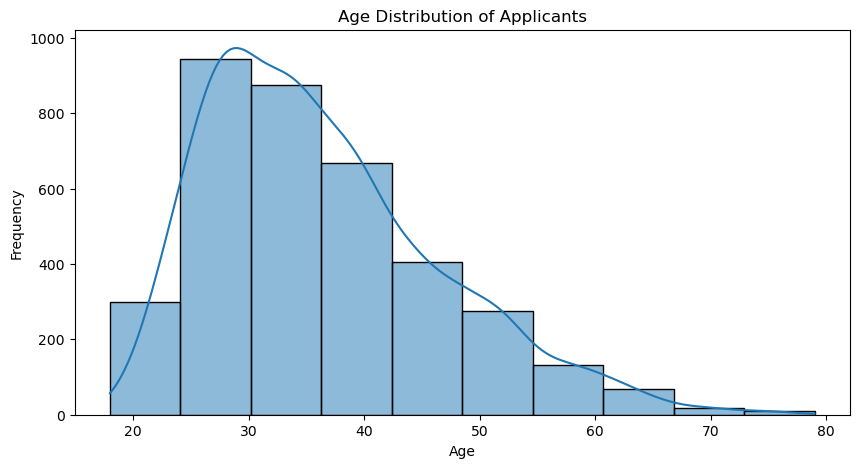

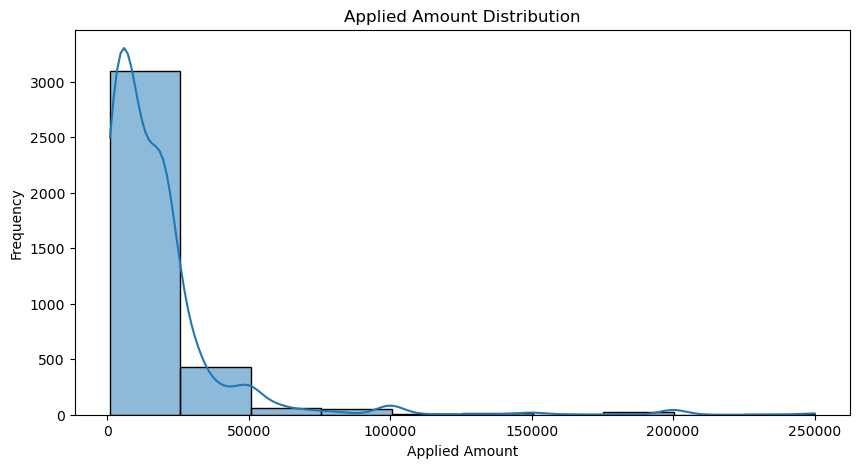

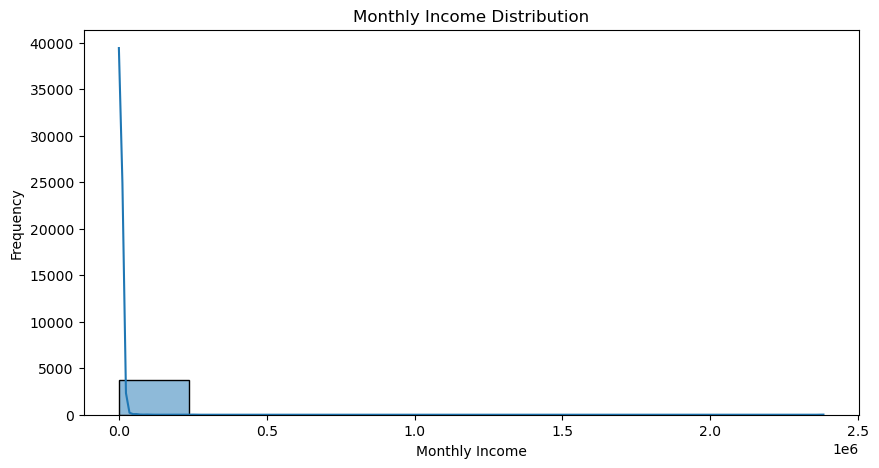

In [202]:
# Distribution of Age
plt.figure(figsize=(10, 5))
sns.histplot(applications['age'], bins=10, kde=True)
plt.title('Age Distribution of Applicants')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Distribution of Applied Amount
plt.figure(figsize=(10, 5))
sns.histplot(applications['appliedAmount'], bins=10, kde=True)
plt.title('Applied Amount Distribution')
plt.xlabel('Applied Amount')
plt.ylabel('Frequency')
plt.show()

# Distribution of Monthly Income
plt.figure(figsize=(10, 5))
sns.histplot(applications['monthlyIncome'], bins=10, kde=True)
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()

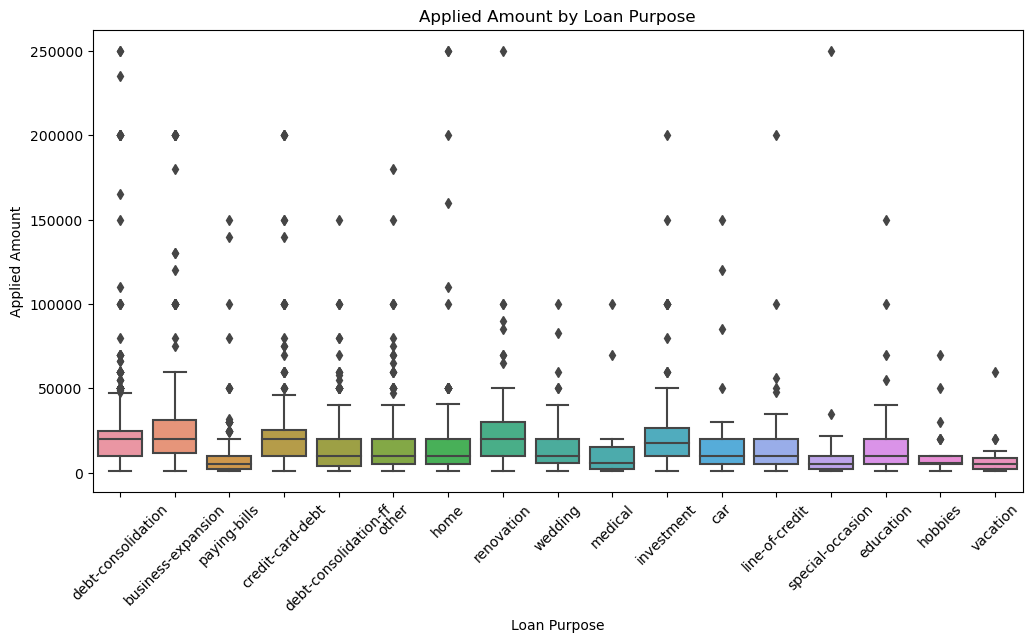

In [204]:
# Box plot for applied amount by loan purpose
plt.figure(figsize=(12, 6))
sns.boxplot(data=applications, x='loanPurpose', y='appliedAmount')
plt.title('Applied Amount by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Applied Amount')
plt.xticks(rotation=45)
plt.show()

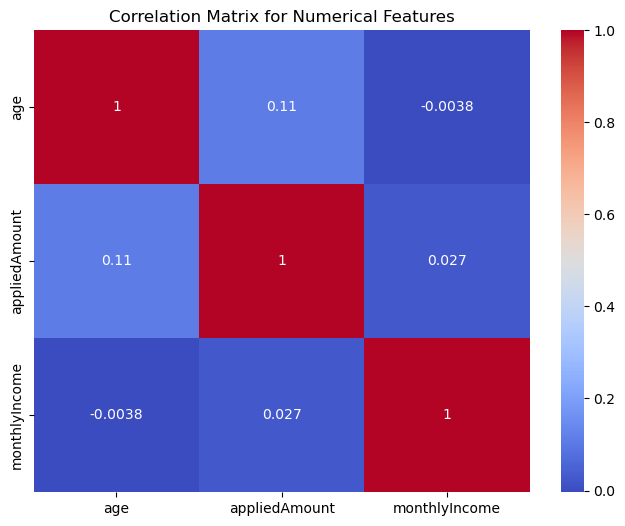

In [239]:
# Correlation matrix for numerical columns in applications
correlation_matrix = applications[['age', 'appliedAmount', 'monthlyIncome']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [205]:
merged_data = pd.merge(applications, offers, on='appId', how='left')

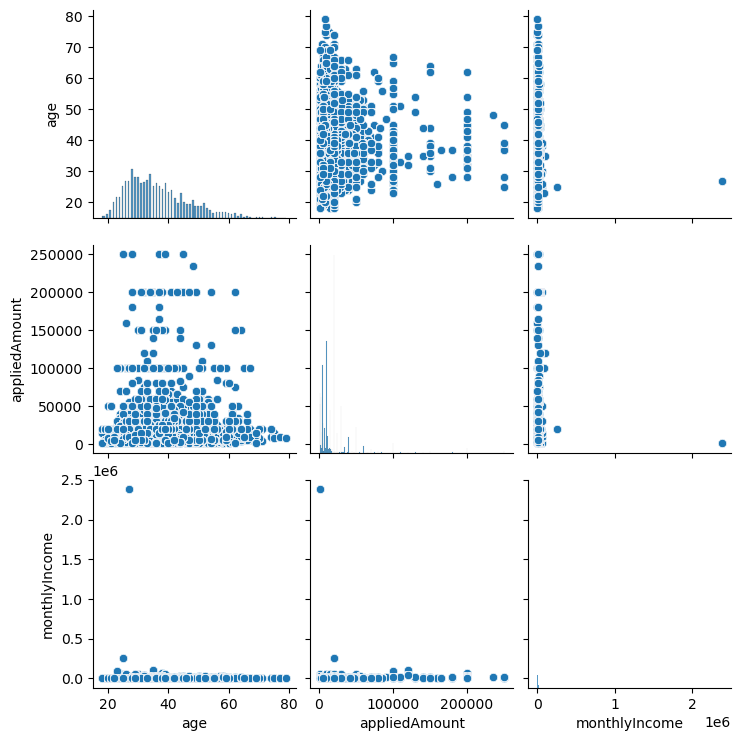

In [206]:
sns.pairplot(merged_data)

In [207]:
approval_rates = merged_data.groupby('loanPurpose')['offer_status_name'].value_counts(normalize=True).unstack().fillna(0)

In [208]:
approval_rates.head()

offer_status_name,Acknowledged,Bank Approved IPA,Bank Declined IPA,Chosen - Lender Review,Chosen - Manual Review,Customer Reject IPA/LG,Loan Disbursed IPA/LG,Loan Rejected - Post,Loan Rejected - Pre,PR Fail IPA/LG,Pending IPA,Queued
loanPurpose,,,,,,,,,,,,
business-expansion,0.000404,0.207873,0.222432,0.000000,0.00000,0.003909,0.004718,0.006471,0.000539,0.141143,0.035050,0.377460
car,0.001080,0.196650,0.157212,0.000000,0.00000,0.004862,0.003241,0.006483,0.000000,0.144246,0.032415,0.453809
credit-card-debt,0.000117,0.215410,0.198275,0.000117,0.00000,0.003613,0.003847,0.002564,0.000233,0.075417,0.039748,0.460660
debt-consolidation,0.000516,0.152334,0.365094,0.000000,0.00004,0.003732,0.004486,0.006273,0.000715,0.129983,0.043751,0.293076
debt-consolidation-ff,0.000442,0.164367,0.230875,0.000166,0.00000,0.004471,0.004747,0.006734,0.000442,0.235236,0.036925,0.315598


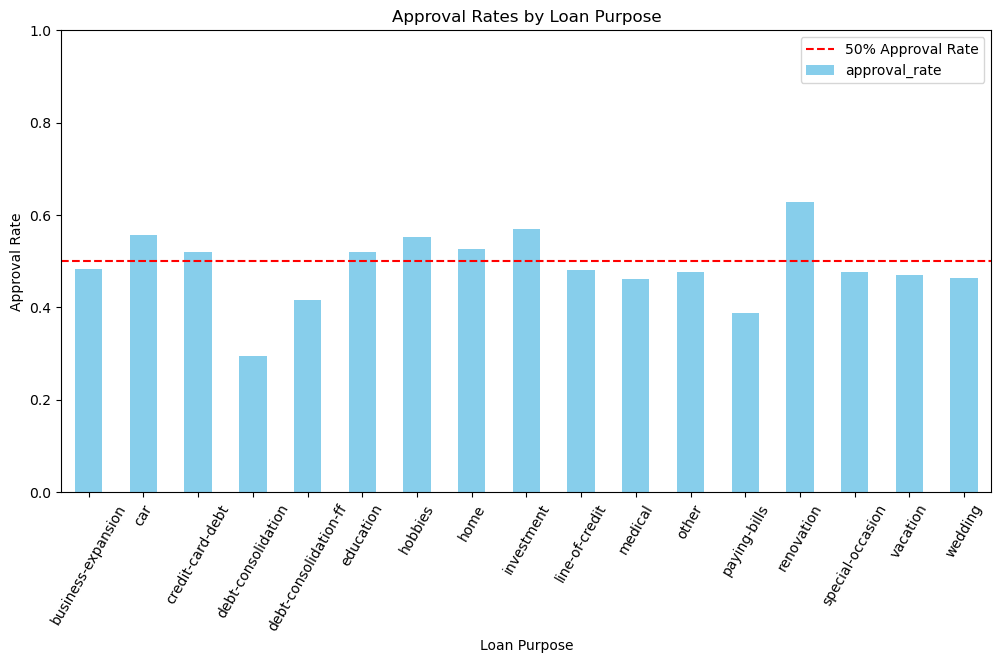

In [209]:
# Calculate approval rates by loan purpose
approval_rates = merged_data.groupby('loanPurpose')['offer_status_name'].value_counts(normalize=True).unstack().fillna(0)
approval_rates['approval_rate'] = approval_rates['Bank Approved IPA'] / (approval_rates['Bank Approved IPA'] + approval_rates['Bank Declined IPA'])

plt.figure(figsize=(12, 6))
approval_rates['approval_rate'].plot(kind='bar', color='skyblue')
plt.title('Approval Rates by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Approval Rate')
plt.xticks(rotation = 60)
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linestyle='--', label='50% Approval Rate')
plt.legend()
plt.show()

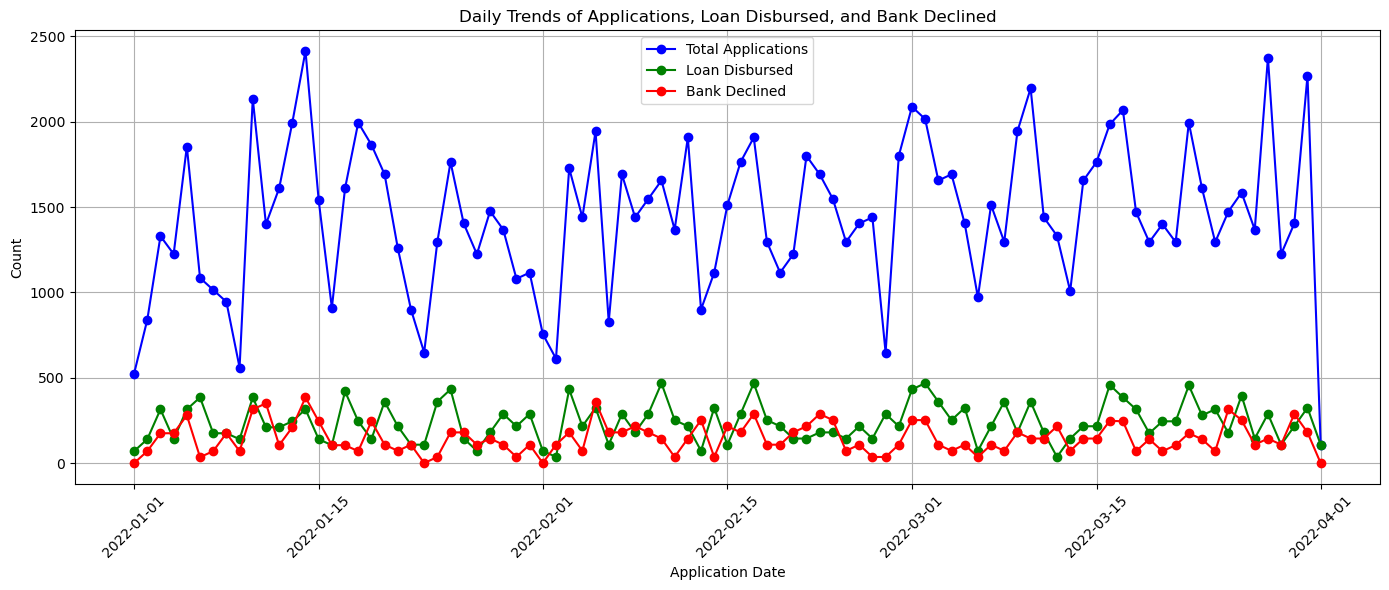

In [210]:
#Monthly Trends of Applications and Offers

merged_data['application_date'] = merged_data['applicationTime'].dt.date

# Count applications, loan disbursed, and bank declined by day
daily_trends = merged_data.groupby('application_date').agg(
    total_applications=('appId', 'count'),  # Count of total applications
    loan_disbursed=('applic_status_name', lambda x: (x == 'Loan Disbursed App').sum()),  # Count of loan disbursed
    bank_declined=('applic_status_name', lambda x: (x == 'Bank Declined App').sum())  # Count of bank declined
)

daily_trends.reset_index(inplace=True)


plt.figure(figsize=(14, 6))
plt.plot(daily_trends['application_date'], daily_trends['total_applications'], marker='o', label='Total Applications', color='blue')
plt.plot(daily_trends['application_date'], daily_trends['loan_disbursed'], marker='o', label='Loan Disbursed', color='green')
plt.plot(daily_trends['application_date'], daily_trends['bank_declined'], marker='o', label='Bank Declined', color='red')
plt.title('Daily Trends of Applications, Loan Disbursed, and Bank Declined')
plt.xlabel('Application Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

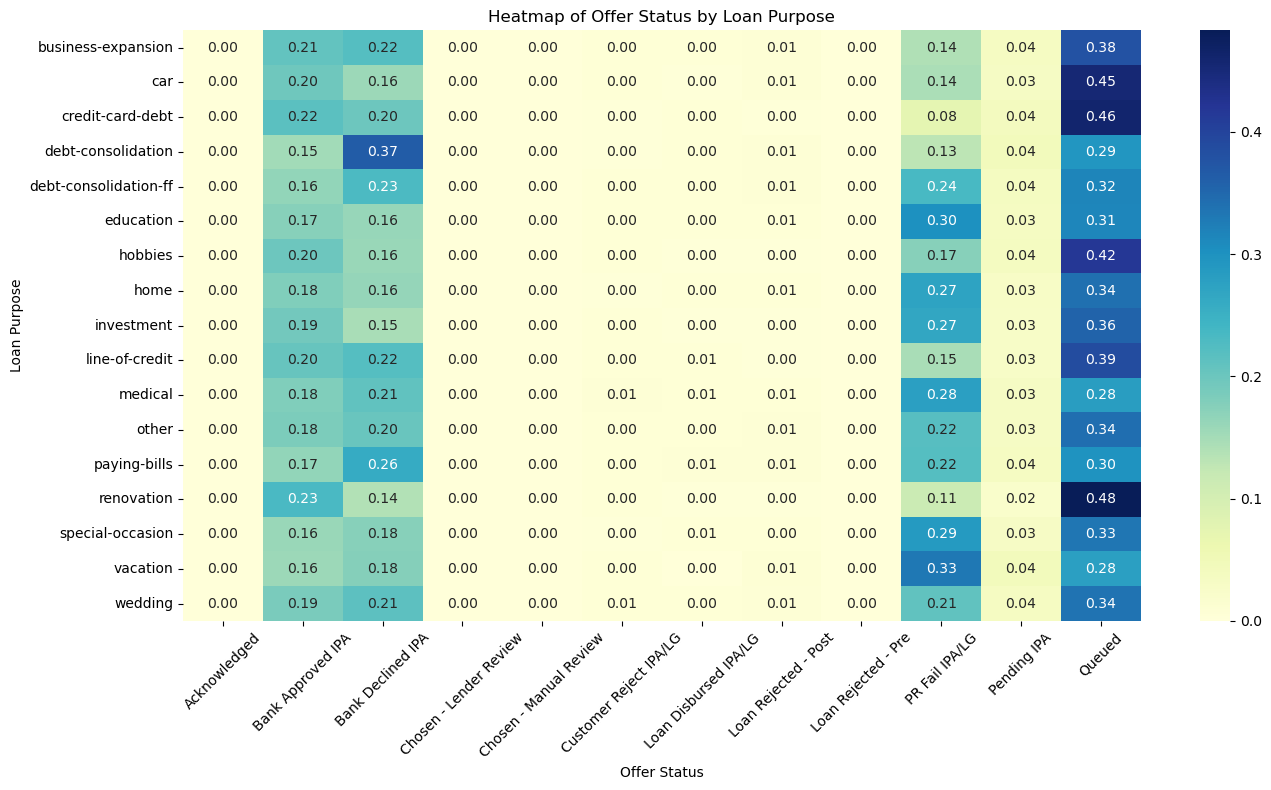

In [211]:
# heatmap
heatmap_data = pd.crosstab(index=merged_data['loanPurpose'], 
                            columns=merged_data['offer_status_name'])

heatmap_data_normalized = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data_normalized, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Heatmap of Offer Status by Loan Purpose')
plt.xlabel('Offer Status')
plt.ylabel('Loan Purpose')
plt.xticks(rotation=45)  
plt.tight_layout()       
plt.show()

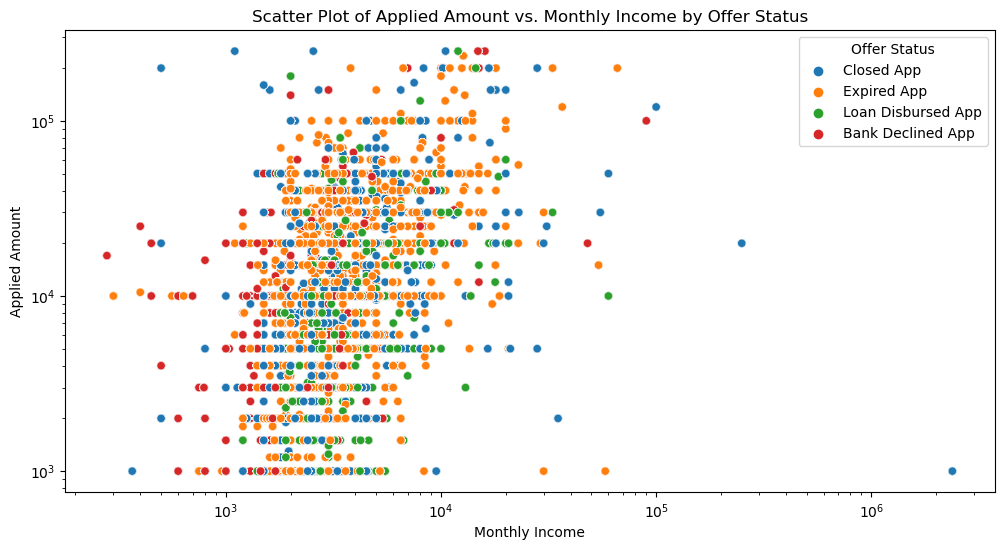

In [212]:
# Scatter Plot of Applied Amount vs. Monthly Income by Offer Status
plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_data, x='monthlyIncome', y='appliedAmount', hue='applic_status_name', alpha=0.6)
plt.title('Scatter Plot of Applied Amount vs. Monthly Income by Offer Status')
plt.xlabel('Monthly Income')
plt.ylabel('Applied Amount')
plt.xscale('log')  # Log scale to handle large ranges
plt.yscale('log') 

plt.legend(title='Offer Status')
plt.show()

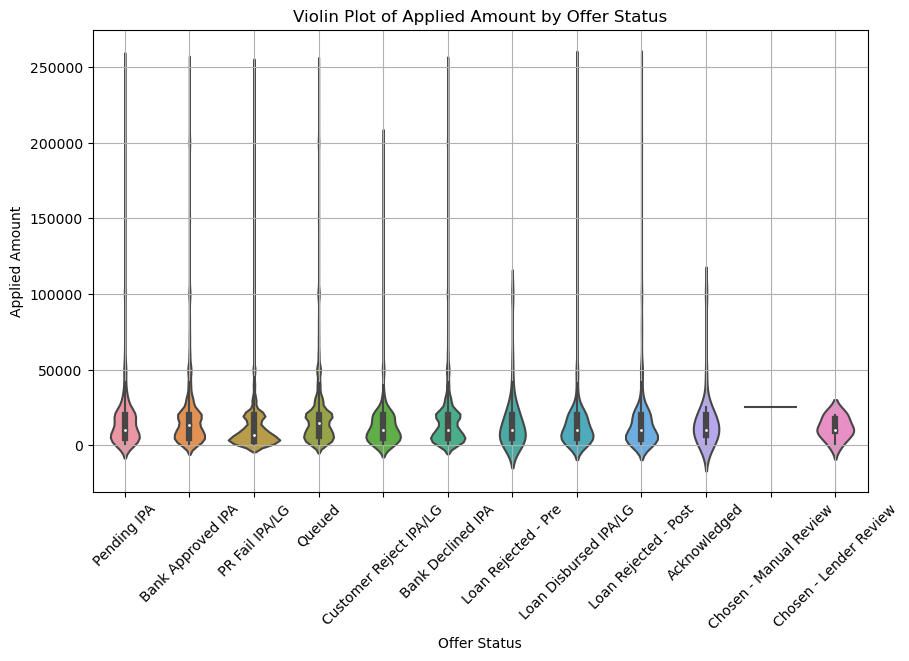

In [213]:
#violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=merged_data, x='offer_status_name', y='appliedAmount')
plt.title('Violin Plot of Applied Amount by Offer Status')
plt.xlabel('Offer Status')
plt.ylabel('Applied Amount')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [214]:
merged_data = merged_data.drop(['salesName', 'appId', 'applicationTime', 'pendingOfferTime', 'offerGivenTime', 'offerChosenTime', 'disburseTime', 'application_date', 'offerId', 'lenderName'], axis=1)

In [215]:
merged_data.columns

Index(['applic_status_name', 'age', 'appliedAmount', 'civilStatus',
       'loanPurpose', 'monthlyIncome', 'nationality', 'residency',
       'workStatus', 'jobIndustry', 'leadSource', 'offer_status_name'],
      dtype='object')

In [216]:
print(merged_data['offer_status_name'].unique())

['Pending IPA' 'Bank Approved IPA' 'PR Fail IPA/LG' 'Queued'
 'Customer Reject IPA/LG' 'Bank Declined IPA' 'Loan Rejected - Pre'
 'Loan Disbursed IPA/LG' 'Loan Rejected - Post' 'Acknowledged'
 'Chosen - Manual Review' 'Chosen - Lender Review']


In [218]:
data = pd.get_dummies(merged_data, columns=['applic_status_name', 'civilStatus', 'loanPurpose', 'nationality', 'residency', 'workStatus', 'jobIndustry', 'leadSource'], drop_first=True)

In [219]:
numerical_features = ['monthlyIncome', 'appliedAmount', 'age'] 
scaler = StandardScaler()

In [220]:
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [221]:
X = data.drop('offer_status_name', axis=1)  
y = data['offer_status_name'] 

In [222]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (105332, 111) (105332,)
Testing set shape: (26333, 111) (26333,)


In [223]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [224]:
y_pred_logistic = logistic_model.predict(X_test)

In [226]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
confusion_logistic = confusion_matrix(y_test, y_pred_logistic)
report_logistic = classification_report(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Logistic Regression Accuracy: 0.46360080507348195


/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [227]:
print("Confusion Matrix:\n", confusion_logistic)

Confusion Matrix:
 [[   0    0    3    0    0    0    0    4    0    6]
 [   0   16  615    0    0    0    0  355    1 3716]
 [   0    7 1824    0    0    0    0  686    2 3686]
 [   0    0   16    0    0    0    0   14    0   86]
 [   0    0   20    0    0    0    0   16    0   99]
 [   0    0   32    0    0    0    0   15    0   99]
 [   0    0    4    0    0    0    0    0    0    3]
 [   0   21  655    0    0    0    0 2954    0 1522]
 [   0    2  192    0    0    0    0   86    3  619]
 [   0   19 1205    0    0    0    0  316    3 7411]]


In [228]:
print("Classification Report:\n", report_logistic)

Classification Report:
                         precision    recall  f1-score   support

          Acknowledged       0.00      0.00      0.00        13
     Bank Approved IPA       0.25      0.00      0.01      4703
     Bank Declined IPA       0.40      0.29      0.34      6205
Customer Reject IPA/LG       0.00      0.00      0.00       116
 Loan Disbursed IPA/LG       0.00      0.00      0.00       135
  Loan Rejected - Post       0.00      0.00      0.00       146
   Loan Rejected - Pre       0.00      0.00      0.00         7
        PR Fail IPA/LG       0.66      0.57      0.62      5152
           Pending IPA       0.33      0.00      0.01       902
                Queued       0.43      0.83      0.57      8954

              accuracy                           0.46     26333
             macro avg       0.21      0.17      0.15     26333
          weighted avg       0.43      0.46      0.39     26333



In [229]:
# Initialize the model
decision_tree_model = DecisionTreeClassifier()

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

In [230]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
confusion_tree = confusion_matrix(y_test, y_pred_tree)
report_tree = classification_report(y_test, y_pred_tree)

print("Decision Tree Classifier Accuracy:", accuracy_tree)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Decision Tree Classifier Accuracy: 0.5451714578665553


/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [231]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.5425892041346738


In [235]:
importances = decision_tree_model.feature_importances_

Feature Importances:
                            Feature  Importance
57              residency_spass-wp    0.278401
2                    monthlyIncome    0.276121
0                              age    0.087921
1                    appliedAmount    0.049917
11  loanPurpose_debt-consolidation    0.030449
..                             ...         ...
32                  nationality_HK    0.000000
25                  nationality_AU    0.000000
78    leadSource_best_in_singapore    0.000000
43                  nationality_NO    0.000000
26                  nationality_AX    0.000000

[111 rows x 2 columns]


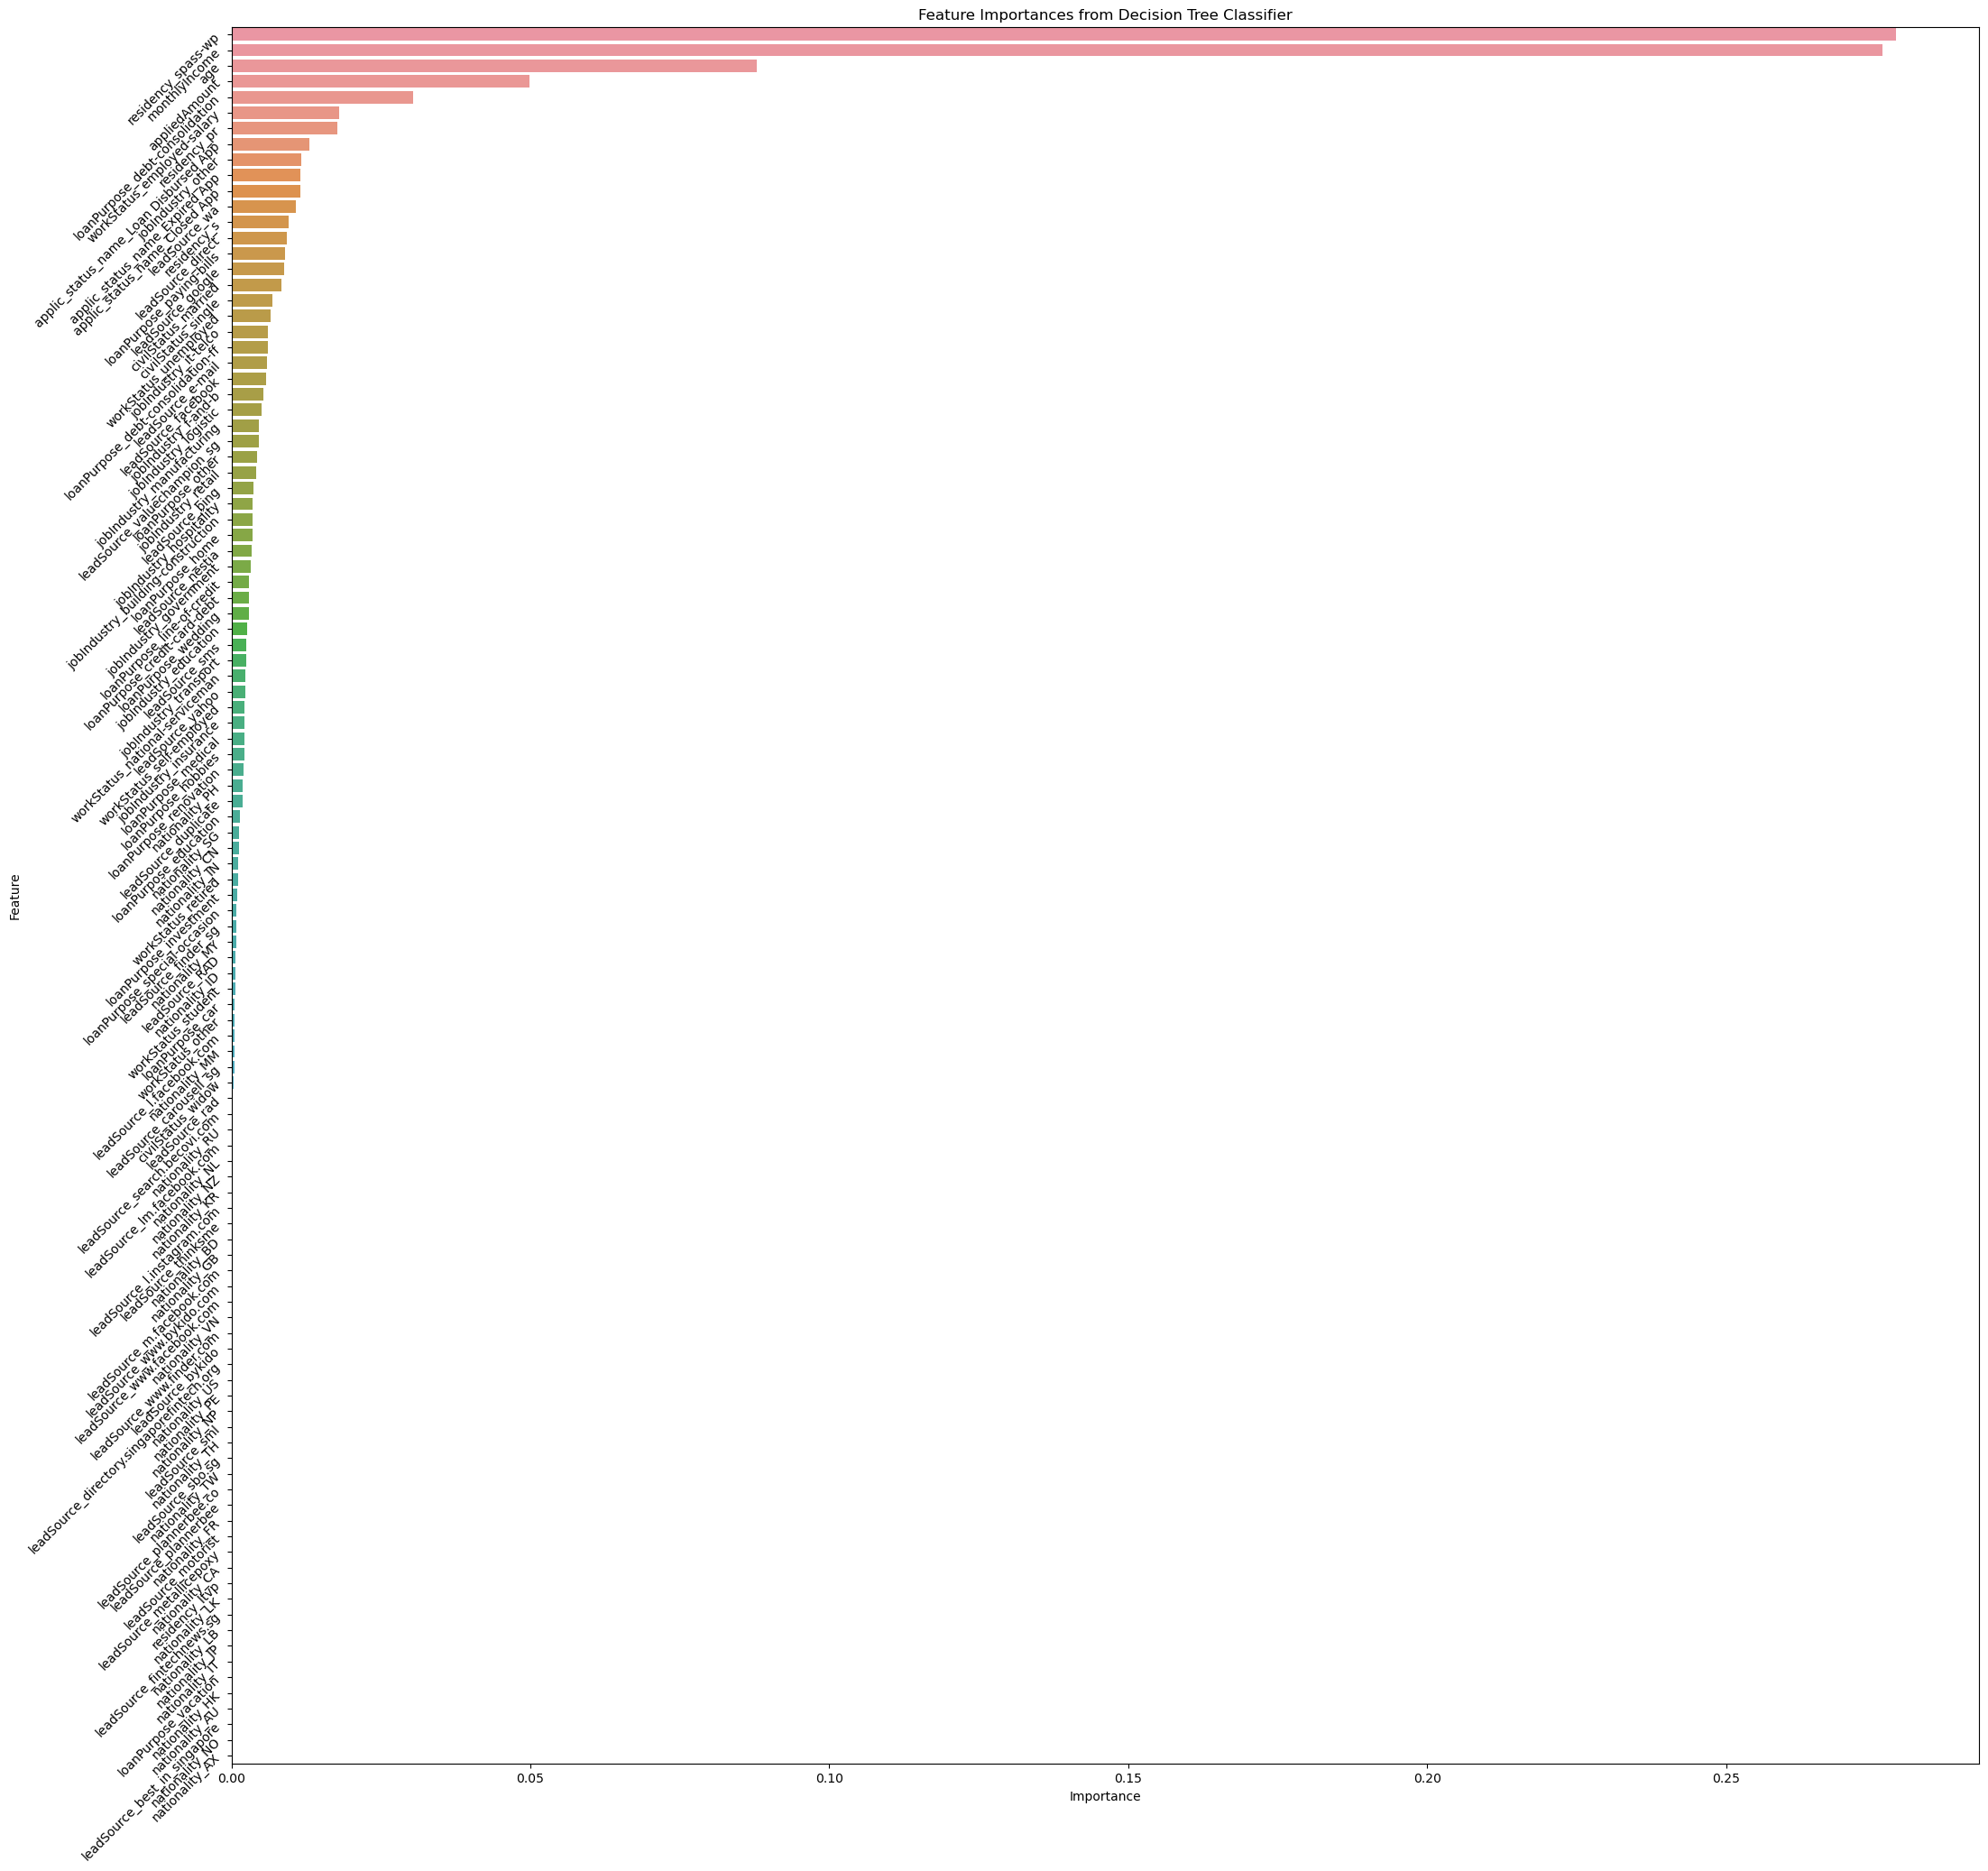

In [243]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the feature importances
print("Feature Importances:\n", feature_importances)

plt.figure(figsize=(25, 25))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances from Decision Tree Classifier')
plt.yticks(rotation = '45')
plt.show()

In [232]:
best_tree_model = DecisionTreeClassifier(**best_params)
best_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [233]:
y_pred_best_tree = best_tree_model.predict(X_test)
accuracy_best_tree = accuracy_score(y_test, y_pred_best_tree)

In [234]:
print(f"Tuned Decision Tree Classifier Accuracy: {accuracy_best_tree:.2f}")


Tuned Decision Tree Classifier Accuracy: 0.55


Final Model Comparison:
Logistic Regression Accuracy: 0.46
Decision Tree Classifier Accuracy (Before Tuning): 0.55
Tuned Decision Tree Classifier Accuracy: 0.55


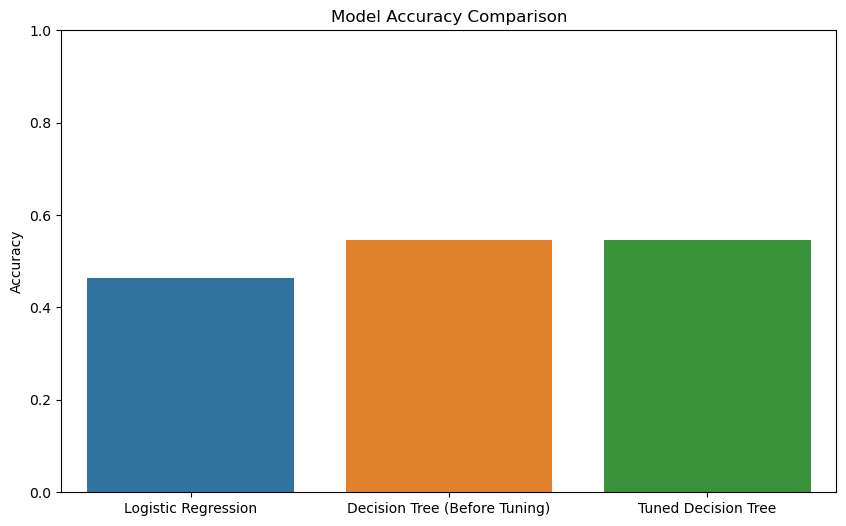

In [237]:
# Summary of results
print("Final Model Comparison:")
print(f"Logistic Regression Accuracy: {accuracy_logistic:.2f}")
print(f"Decision Tree Classifier Accuracy (Before Tuning): {accuracy_tree:.2f}")
print(f"Tuned Decision Tree Classifier Accuracy: {accuracy_best_tree:.2f}")

model_names = ['Logistic Regression', 'Decision Tree (Before Tuning)', 'Tuned Decision Tree']
accuracies = [accuracy_logistic, accuracy_tree, accuracy_best_tree]

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1) 
plt.show()